# P-wave-earthquake-localisation-toy-box exemple notebook

In [1]:
import numpy as np

In [2]:
import generate_eq
import graphics
import commons

In [3]:
import Gauss_Newton
import Levenberg_Marquardt
import Uniq_searcher
import deepening_grid

In [4]:

# Deffine the stations, world box and V-P
#                        X       Y     Z    t
stations = np.array([[   0.0,  700.0,  0.0, 0.0],  # N°1
                     [ 700.0, 1000.0,  0.0, 0.0],  # N°2
                     [1000.0,  300.0,  0.0, 0.0],  # N°3
                     [ 500.0,  500.0, 10.0, 0.0],  # N°4
                     [ 400.0,    0.0,  0.0, 0.0]]) # N°5

box_gen = np.array([[    0.0,  1000.0],
                    [    0.0,  1000.0],
                    [-1000.0,     0.0]])

vp = 4000.0 # m/s

# Generate a random event without any noise
event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)
print(f'Event before normalisation:\n\t{event}\n')

# Normalise the stations
stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                   'Z':float(event_norm[2]), 't':float(event_norm[3])}

print(f'Event after normalisation:\n\t{event_norm_dict}\n')

# Compute the normalised world box
limites = np.column_stack((np.min(stations_norm, axis=0), np.max(stations_norm, axis=0)))
limites[2, 0] = -1000

# Set the initialisation to be the same for all iterative solver
event_ini = np.random.rand(4)
event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
event_ini[2] = min(event_ini[2], -1)
event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                  'Z':float(event_ini[2]), 't':float(event_ini[3])}

print(f'Initialisation:\n\t{event_ini_dict}\n')

Results = {}

Event before normalisation:
	{'X': 833.2946791380103, 'Y': 350.5582551729176, 'Z': -34.55832249808293, 't': 1785333758.2312164}

Event after normalisation:
	{'X': 333.29467913801034, 'Y': -149.4417448270824, 'Z': -44.55832249808293, 't': -0.09199309349060059}

Initialisation:
	{'X': 316.94086067585374, 'Y': -463.192973554353, 'Z': -135.06221848714733, 't': -0.02186578806220037}



In [5]:
event_best_GN, history_GN, cost_story_GN, misfit_fin_GN = Gauss_Newton.Gauss_Newton(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_GN}')
print(f'\t- Event = {event_best_GN}')

Results['Gauss-Newton'] = {'X':event_best_GN['X'],
                           'Y':event_best_GN['Y'],
                           'Z':event_best_GN['Z'],
                           't':event_best_GN['t'],
                           'RMSE':misfit_fin_GN}

_ = graphics.history_2d(cost_story_GN, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_GN[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_GN[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 4.799643903368758e-09
	- Event = {'X': 333.29491903567543, 'Y': -149.44147210715013, 'Z': -44.55958920012823, 't': -0.09199314096147676}


In [6]:
event_best_LM, history_LM, cost_story_LM, misfit_fin_LM = Levenberg_Marquardt.Levenberg_Marquardt(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_LM}')
print(f'\t- Event = {event_best_LM}')

Results['Levenberg-Marquardt'] = {'X':event_best_LM['X'],
                                  'Y':event_best_LM['Y'],
                                  'Z':event_best_LM['Z'],
                                  't':event_best_LM['t'],
                                  'RMSE':misfit_fin_LM}

_ = graphics.history_2d(cost_story_LM, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_LM[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_LM[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 4.799643907509035e-09
	- Event = {'X': 333.29491903567543, 'Y': -149.4414721071501, 'Z': -44.55958920012837, 't': -0.09199314096147676}


Best fitt with:
	- RMSE = 9.589512786213029e-09
	- Event = {'X': 333.2948650289332, 'Y': -149.4414510009961, 'Z': -44.558662935471915, 't': -0.09199311329294381}


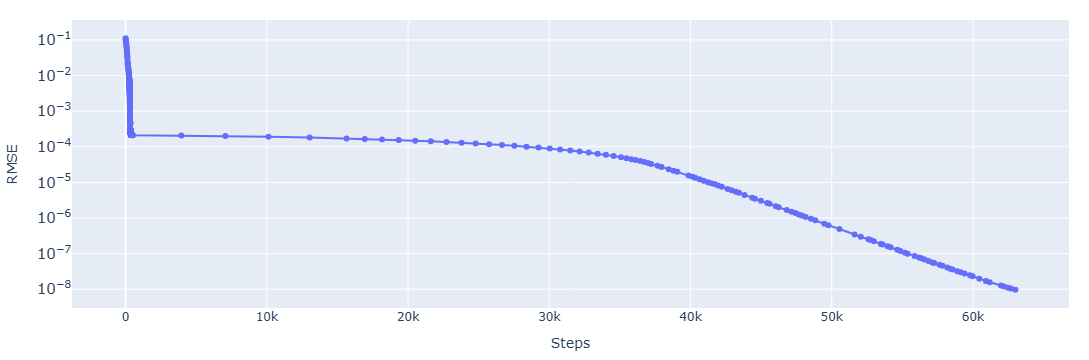

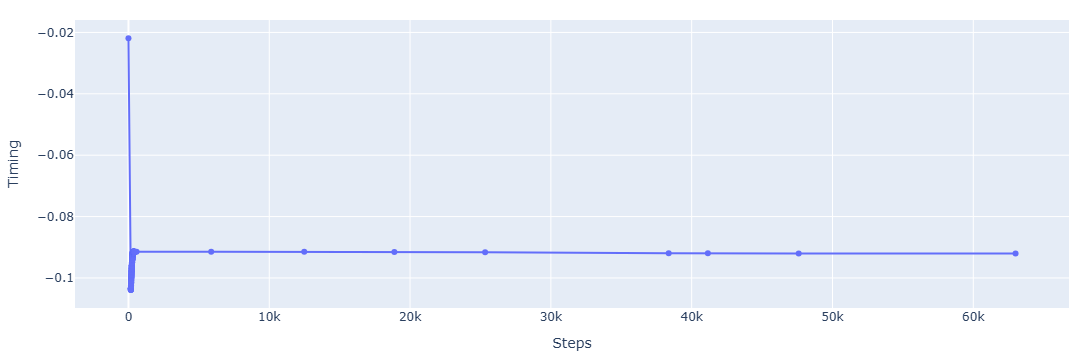

In [7]:
event_best_US, history_US, cost_story_US, misfit_fin_US = Uniq_searcher.gradient_descent(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=200_000,
    ranX=1,
    ranY=1,
    ranZ=1,
    rant=0.0005,
    lr_decay=0.05,
    patience=500,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_US}')
print(f'\t- Event = {event_best_US}')

Results['Unique searcher'] = {'X':event_best_US['X'],
                              'Y':event_best_US['Y'],
                              'Z':event_best_US['Z'],
                              't':event_best_US['t'],
                              'RMSE':misfit_fin_US}

_ = graphics.history_2d(cost_story_US, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_US[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_US[:, :3], stations_norm, filename=None)

In [8]:
event_best_DG, history_DG, cost_story_DG, misfit_fin_DG = deepening_grid.deepening_grid_search(
    stations=stations_norm,
    sampling_f=21,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DG}')
print(f'\t- Event = {event_best_DG}')

Results['Deepening grid'] = {'X':event_best_DG['X'],
                             'Y':event_best_DG['Y'],
                             'Z':event_best_DG['Z'],
                             't':event_best_DG['t'],
                             'RMSE':misfit_fin_DG}

_ = graphics.history_2d(cost_story_DG, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DG[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DG[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 7.207108500332607e-05
	- Event = {'X': 335.8697509765625, 'Y': -150.55181884765625, 'Z': 48.82166290283203, 't': -0.09287483245134354}


In [9]:
event_best_DS, history_DS, cost_story_DS, misfit_fin_DS = deepening_grid.deepening_grid_sampling(
    stations=stations_norm,
    sampling_f=6,
    limites=np.copy(limites),
    depth=1001,
    halving_rate=0.20,
    n_samples=100,
    vp=4000.0)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_DS}')
print(f'\t- Event = {event_best_DS}')

Results['Deepening sampling'] = {'X':event_best_DS['X'],
                                 'Y':event_best_DS['Y'],
                                 'Z':event_best_DS['Z'],
                                 't':event_best_DS['t'],
                                 'RMSE':misfit_fin_DS}

_ = graphics.history_2d(cost_story_DS, 'RMSE', log_y=True, filename=None)
_ = graphics.history_2d(history_DS[:, 3], 'Timing', filename=None)
_ = graphics.history_3d(history_DS[:, :3], stations_norm, filename=None)

Best fitt with:
	- RMSE = 7.207380168919078e-05
	- Event = {'X': 335.87774658203125, 'Y': -150.55523681640625, 'Z': 48.89381408691406, 't': -0.0928783118724823}


In [10]:
# Making some comparison
_ = graphics.solver_compare(Results,
                            None,
                            None,
                            title="Solver Comparison",
                            colorscale="Viridis",
                            filename=None,
                            height=1000)

In [12]:
_ = graphics.build_tables(Results, rounding=12)

+---------------------+------------------+-------------------+------------------+-----------------+--------------+
|       Models        |        X         |         Y         |        Z         |        t        | RMSE (10^-5) |
+---------------------+------------------+-------------------+------------------+-----------------+--------------+
|    Gauss-Newton     | 333.294919035675 | -149.44147210715  | -44.559589200128 | -0.091993140961 |   0.00048    |
+---------------------+------------------+-------------------+------------------+-----------------+--------------+
| Levenberg-Marquardt | 333.294919035675 | -149.44147210715  | -44.559589200128 | -0.091993140961 |   0.00048    |
+---------------------+------------------+-------------------+------------------+-----------------+--------------+
|   Unique searcher   | 333.294865028933 | -149.441451000996 | -44.558662935472 | -0.091993113293 |   0.000959   |
+---------------------+------------------+-------------------+------------------